# Day 17: Build Your First CNN

> **Goal:** Build a CNN from scratch, train it on CIFAR-10, and understand how conv → pool → conv → pool → FC works.

---

## CNN Architecture Overview

A typical CNN has:
1. **Feature extractor** — stacked Conv + BN + ReLU + Pool layers
2. **Classifier head** — Flatten + Linear layers

```
Input (3, 32, 32)
  → Conv(3→32, 3×3) → BN → ReLU → MaxPool(2)    → (32, 16, 16)
  → Conv(32→64, 3×3) → BN → ReLU → MaxPool(2)   → (64, 8, 8)
  → Conv(64→128, 3×3) → BN → ReLU → MaxPool(2)  → (128, 4, 4)
  → Flatten                                        → (2048)
  → Linear(2048, 256) → ReLU → Dropout
  → Linear(256, 10)
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## Data Setup with Augmentation

Before building the CNN, we prepare CIFAR-10 with **data augmentation** — random flips and crops during training. This is like showing the network slightly different views of each image, which helps prevent overfitting (recall Day 12).

**Why augment?** CIFAR-10 only has 50,000 training images. Augmentation artificially increases diversity without collecting more data. We also normalize using CIFAR-10's pre-computed mean and standard deviation per channel.

In [2]:
# Data setup with augmentation
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_data  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_data, val_data = random_split(full_train, [train_size, val_size],
                                     generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

classes = full_train.classes
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train: 45000, Val: 5000, Test: 10000
Train batches: 352, Val batches: 40, Test batches: 79


---
## 1. Define the CNN

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(
            # Block 1: 3 → 32 channels, 32×32 → 16×16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 32 → 64 channels, 16×16 → 8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 64 → 128 channels, 8×8 → 4×4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)
print(model)

# Count parameters
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_featur

### Verify: Trace Shapes Through the Network

A crucial debugging habit — **always verify tensor shapes** by passing a dummy input through your model. This catches dimension mismatches before training. Watch how the spatial dimensions shrink (32→16→8→4) while channels grow (3→32→64→128):

In [4]:
# Verify shapes through the network
x = torch.randn(1, 3, 32, 32).to(device)
print(f"Input:        {x.shape}")

# Trace through features block by block
for i, layer in enumerate(model.features):
    x = layer(x)
    if isinstance(layer, (nn.MaxPool2d, nn.Conv2d)):
        print(f"After {layer.__class__.__name__:12s}: {x.shape}")

x = model.classifier(x)
print(f"Output:       {x.shape}")

Input:        torch.Size([1, 3, 32, 32])
After Conv2d      : torch.Size([1, 32, 32, 32])
After MaxPool2d   : torch.Size([1, 32, 16, 16])
After Conv2d      : torch.Size([1, 64, 16, 16])
After MaxPool2d   : torch.Size([1, 64, 8, 8])
After Conv2d      : torch.Size([1, 128, 8, 8])
After MaxPool2d   : torch.Size([1, 128, 4, 4])
Output:       torch.Size([1, 10])


---
## 2. Training Infrastructure

In [5]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

Now let's set up the training. Key choices:

- **CrossEntropyLoss** — standard for multi-class classification
- **Adam optimizer** with small weight decay — a good default
- **CosineAnnealingLR** — smoothly decreases the learning rate, which helps the model fine-tune as it converges
- **30 epochs** — enough for CIFAR-10 at this model size

We also print progress every 5 epochs to monitor training.

---
## 3. Train the CNN! 🚀

In [6]:
model = SimpleCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

NUM_EPOCHS = 40
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Time':>5}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
    scheduler.step()
    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_acc:8.2%} | {val_loss:8.4f} | {val_acc:6.2%} | {elapsed:4.1f}s")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |  Time
------------------------------------------------------------
    1 |     1.6125 |   40.41% |   1.3347 | 50.94% |  5.7s
    5 |     1.0098 |   64.55% |   0.9061 | 67.62% |  5.4s
   10 |     0.8406 |   70.73% |   0.7802 | 72.92% |  5.5s
   15 |     0.7374 |   74.69% |   0.6597 | 76.66% |  5.5s
   20 |     0.6602 |   77.60% |   0.6697 | 76.40% |  5.6s
   25 |     0.5967 |   79.71% |   0.6088 | 78.92% |  5.6s
   30 |     0.5594 |   80.96% |   0.5326 | 81.18% |  5.6s
   35 |     0.5260 |   81.94% |   0.5173 | 81.72% |  5.6s
   40 |     0.5119 |   82.54% |   0.5011 | 82.24% |  5.7s


### What to Look For in the Curves

- **Loss decreasing** — the model is learning
- **Train and val curves close together** — no significant overfitting
- **Val curve flattening** — the model has learned what it can from this architecture
- If val loss starts *increasing* while train loss decreases → overfitting (add more regularization)

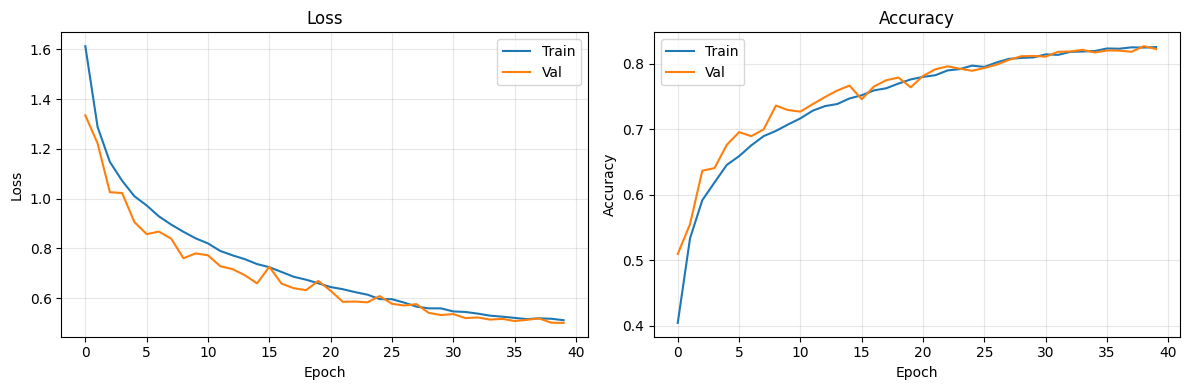

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test Set — The Final Verdict

We only evaluate on the test set **once**, after all tuning is done. This gives us an unbiased estimate of how the model performs on truly unseen data.

In [8]:
# Test set evaluation
test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
print(f"🎯 Test Accuracy: {test_acc:.2%}")

🎯 Test Accuracy: 83.15%


---
## 4. Visualize Learned Filters

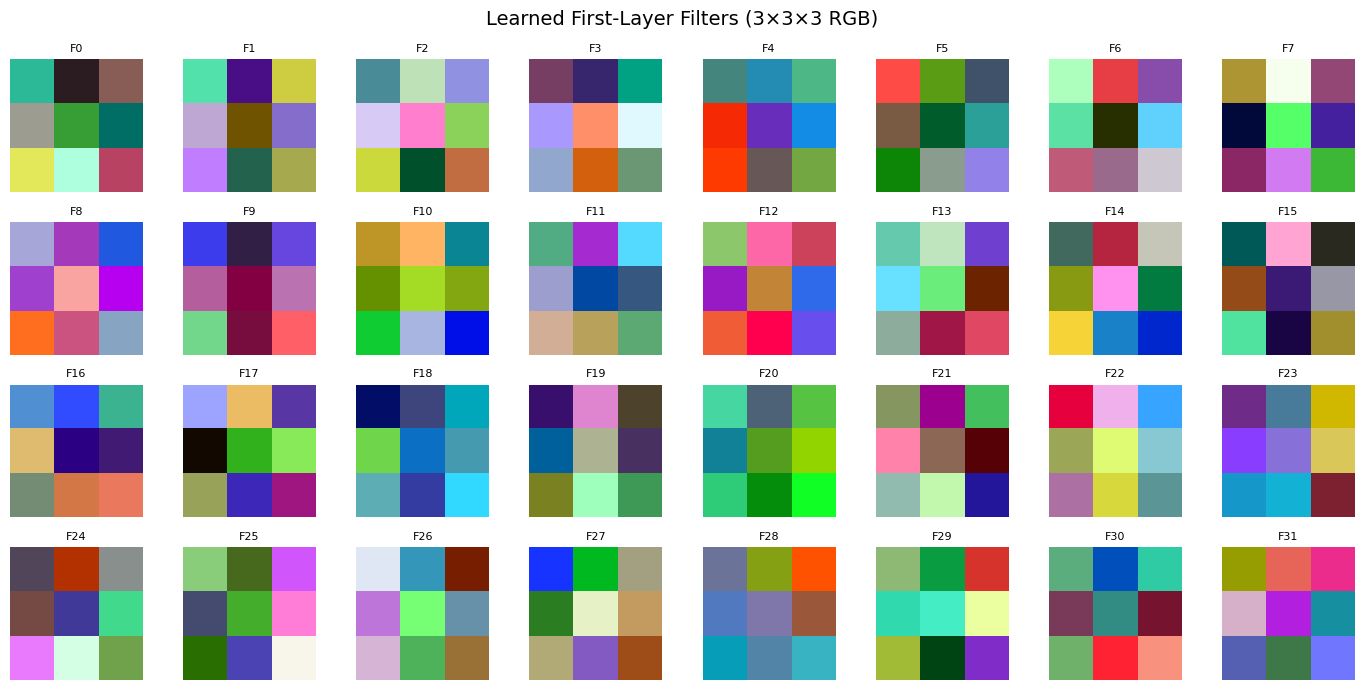

In [9]:
# Visualize first-layer filters (they operate on RGB input)
filters = model.features[0].weight.data.cpu()  # (32, 3, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    f = filters[i]  # (3, 3, 3) — RGB kernel
    # Normalize for display
    f = (f - f.min()) / (f.max() - f.min())
    ax.imshow(f.permute(1, 2, 0))  # (3, 3, 3) → (3, 3, 3)
    ax.axis("off")
    ax.set_title(f"F{i}", fontsize=8)

plt.suptitle("Learned First-Layer Filters (3×3×3 RGB)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Per-Class Accuracy

In [10]:
# Compute per-class accuracy
class_correct = {c: 0 for c in classes}
class_total = {c: 0 for c in classes}

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        for pred, label in zip(preds, labels):
            cls = classes[label]
            class_total[cls] += 1
            if pred == label:
                class_correct[cls] += 1

print(f"{'Class':<12} {'Accuracy':>8} {'Correct/Total':>15}")
print("-" * 38)
for cls in classes:
    acc = class_correct[cls] / class_total[cls]
    print(f"{cls:<12} {acc:>7.1%} {class_correct[cls]:>6}/{class_total[cls]}")

Class        Accuracy   Correct/Total
--------------------------------------
airplane       85.2%    852/1000
automobile     92.6%    926/1000
bird           73.1%    731/1000
cat            64.5%    645/1000
deer           82.1%    821/1000
dog            78.4%    784/1000
frog           89.3%    893/1000
horse          85.5%    855/1000
ship           90.7%    907/1000
truck          90.1%    901/1000


---
## 🧪 Exercises

### Exercise 1: Deeper CNN
Add a 4th conv block (128 → 256 channels). Adjust the flatten size. Does it improve?

### Exercise 2: CNN vs MLP
Compare your CNN accuracy with an MLP (same number of parameters). Why does the CNN win?

### Exercise 3: Visualize feature maps
Pass a test image through the network. Extract and display the feature maps after each conv block.

### Exercise 4: Global Average Pooling
Replace `Flatten + Linear(128*4*4, 256)` with `AdaptiveAvgPool2d(1) + Flatten + Linear(128, 10)`. How many parameters do you save?

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **CNN architecture** | Conv blocks (Conv+BN+ReLU+Pool) → FC head |
| **Progressive features** | Channels ↑ (more features), spatial ↓ (via pooling) |
| **BatchNorm2d** | Normalize across spatial dimensions per channel |
| **~80%+ on CIFAR-10** | Achievable with a simple 3-block CNN |
| **Learned filters** | First layer learns edge/color detectors automatically |

**Tomorrow:** We'll study CNN design patterns — VGG-style blocks and ResNet's skip connections!